# Binary Student Grade Classification Pipeline (EDA, Cleaning, Feature Engineering & ML Models: Decision Tree, Random Forest, XGBoost)

In [1]:
# Import required libraries for data manipulation, visualization, and ML models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

In [2]:
# Load dataset from data folder into pandas dataframe
df = pd.read_csv("../data/sample_data.csv")

In [3]:
# Display first 5 rows of dataframe
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


## 1. Detailed Exploratory Data Analysis (EDA)

In [4]:
# Check shape of dataset to see total rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (806818, 6)


In [5]:
# Display data types of each feature
df.dtypes

student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                       object
dtype: object

In [6]:
# View concise info summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806818 entries, 0 to 806817
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               806818 non-null  int64  
 1   weekly_self_study_hours  806818 non-null  float64
 2   attendance_percentage    806818 non-null  float64
 3   class_participation      806818 non-null  float64
 4   total_score              806818 non-null  float64
 5   grade                    806818 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 36.9+ MB


In [7]:
# Generate summary statistics for numerical features
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,806818.000000,806818.000000,806818.000000,806818.000000,806818.000000
mean,499837.792405,17.052542,84.705655,5.986337,90.251898
std,288726.085534,5.821699,9.427638,1.955247,9.676127
min,1.000000,0.000000,50.000000,0.000000,70.000000
25%,249738.250000,12.900000,78.300000,4.700000,82.100000
50%,499816.500000,16.700000,85.000000,6.000000,92.400000
75%,749828.750000,20.800000,91.700000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [8]:
# Check count of missing values in each column
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [9]:
# Check count of duplicate rows in dataset
df.duplicated().sum()

np.int64(0)

In [10]:
# Count frequencies of the 2 target grade classes
print("Binary Class Frequencies:")
print(df["grade"].value_counts())
print("\nBinary Class Percentages:")
print(df["grade"].value_counts(normalize=True) * 100)

Binary Class Frequencies:
grade
A    548644
B    258174
Name: count, dtype: int64

Binary Class Percentages:
grade
A    68.000962
B    31.999038
Name: proportion, dtype: float64


C:\Users\sumitme752\AppData\Local\Temp\ipykernel_8672\4179543279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="grade", palette="viridis")


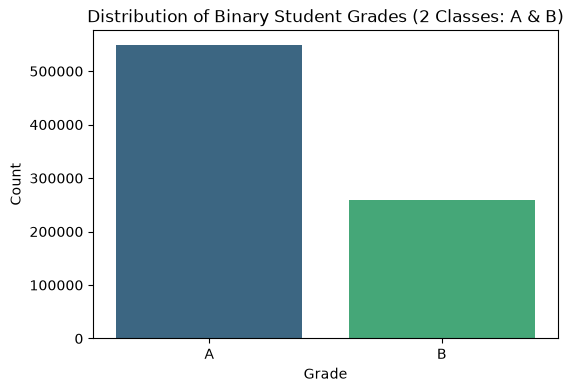

In [11]:
# Plot frequency distribution of the 2 binary grade categories
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="grade", palette="viridis")
plt.title("Distribution of Binary Student Grades (2 Classes: A & B)")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

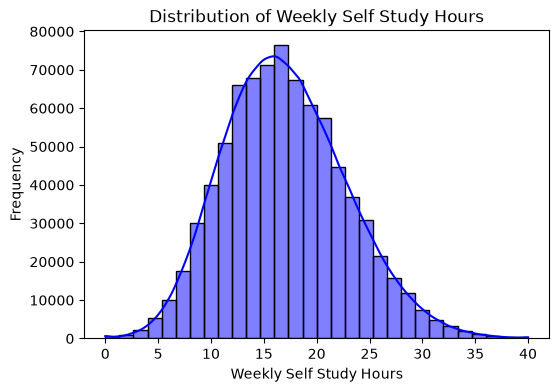

In [12]:
# Plot histogram distribution of weekly self study hours
plt.figure(figsize=(6, 4))
sns.histplot(df["weekly_self_study_hours"], kde=True, color="blue", bins=30)
plt.title("Distribution of Weekly Self Study Hours")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Frequency")
plt.show()

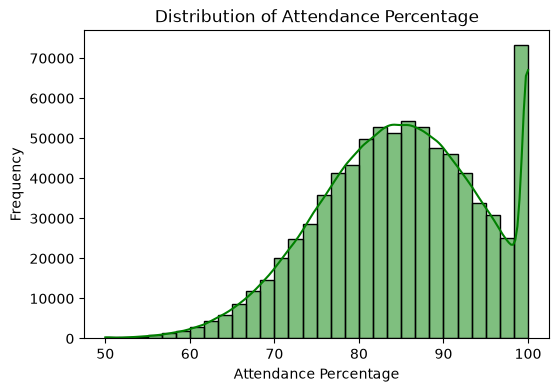

In [13]:
# Plot histogram distribution of attendance percentage
plt.figure(figsize=(6, 4))
sns.histplot(df["attendance_percentage"], kde=True, color="green", bins=30)
plt.title("Distribution of Attendance Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Frequency")
plt.show()

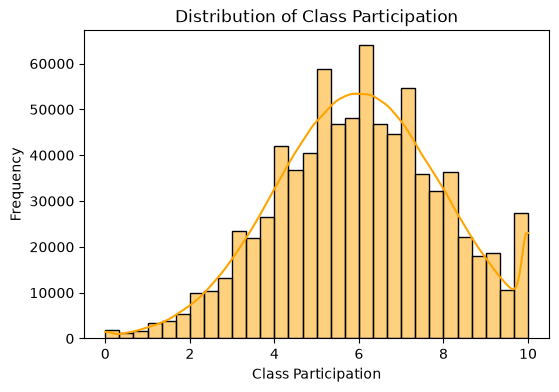

In [14]:
# Plot histogram distribution of class participation
plt.figure(figsize=(6, 4))
sns.histplot(df["class_participation"], kde=True, color="orange", bins=30)
plt.title("Distribution of Class Participation")
plt.xlabel("Class Participation")
plt.ylabel("Frequency")
plt.show()

C:\Users\sumitme752\AppData\Local\Temp\ipykernel_8672\2374101869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="grade", y="weekly_self_study_hours", palette="Set2")


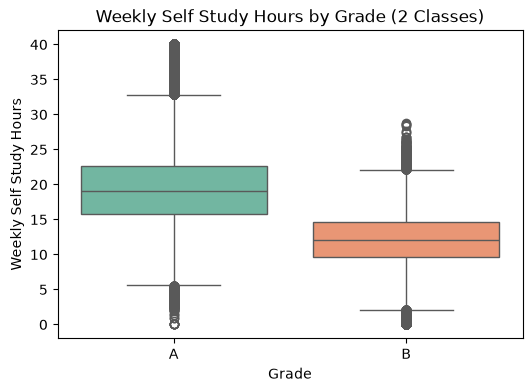

In [15]:
# Plot boxplot showing study hours distribution across binary grade categories
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="grade", y="weekly_self_study_hours", palette="Set2")
plt.title("Weekly Self Study Hours by Grade (2 Classes)")
plt.xlabel("Grade")
plt.ylabel("Weekly Self Study Hours")
plt.show()

C:\Users\sumitme752\AppData\Local\Temp\ipykernel_8672\2130117372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="grade", y="attendance_percentage", palette="Pastel1")


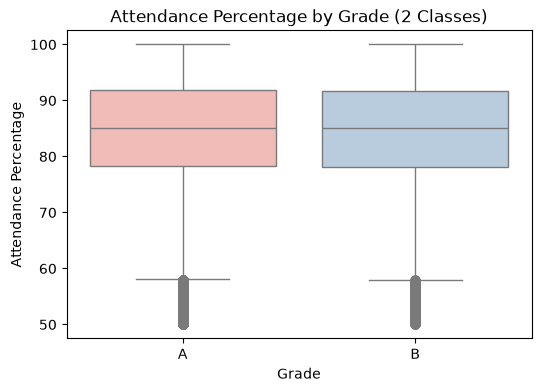

In [16]:
# Plot boxplot showing attendance percentage across binary grade categories
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="grade", y="attendance_percentage", palette="Pastel1")
plt.title("Attendance Percentage by Grade (2 Classes)")
plt.xlabel("Grade")
plt.ylabel("Attendance Percentage")
plt.show()

In [17]:
# Compute correlation matrix for numerical features
num_cols = ["weekly_self_study_hours", "attendance_percentage", "class_participation", "total_score"]
corr_matrix = df[num_cols].corr()
corr_matrix

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
weekly_self_study_hours,1.000000,0.000009,0.001498,0.713613
attendance_percentage,0.000009,1.000000,-0.000275,0.000317
class_participation,0.001498,-0.000275,1.000000,0.000280
total_score,0.713613,0.000317,0.000280,1.000000


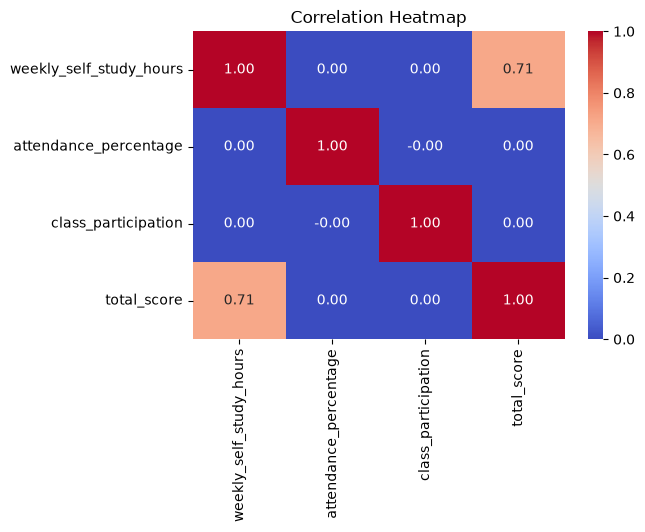

In [18]:
# Display correlation matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 2. Data Cleaning

In [19]:
# Drop student_id uninformative identifier column
df_clean = df.drop(columns=["student_id"])
df_clean.head()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,18.5,95.6,3.8,97.9,A
1,14.0,80.0,2.5,83.9,B
2,19.5,86.3,5.3,100.0,A
3,25.7,70.2,7.0,100.0,A
4,13.4,81.9,6.9,92.0,A


In [20]:
# Fill missing values in numerical columns if any are present
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))
df_clean.isnull().sum()

weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [21]:
# Remove duplicate rows from dataset if present
df_clean = df_clean.drop_duplicates()
print("Cleaned Dataset Shape:", df_clean.shape)

Cleaned Dataset Shape: (789051, 5)


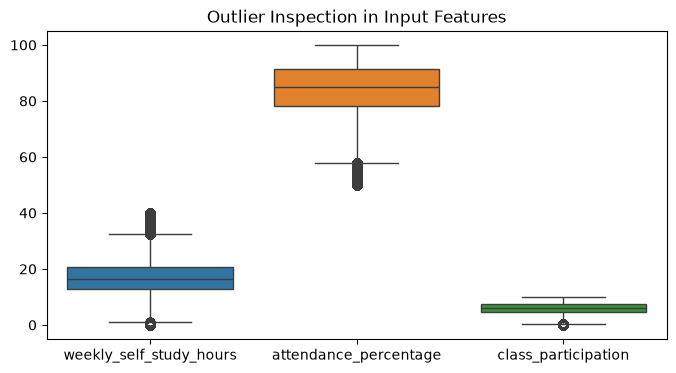

In [22]:
# Inspect feature boxplots to identify potential outliers
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean[["weekly_self_study_hours", "attendance_percentage", "class_participation"]])
plt.title("Outlier Inspection in Input Features")
plt.show()

## 3. Feature Engineering & Target Encoding

In [23]:
# Create new engineered feature study_participation_ratio
df_clean["study_participation_ratio"] = df_clean["weekly_self_study_hours"] * df_clean["class_participation"]
df_clean.head()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,study_participation_ratio
0,18.5,95.6,3.8,97.9,A,70.30
1,14.0,80.0,2.5,83.9,B,35.00
2,19.5,86.3,5.3,100.0,A,103.35
3,25.7,70.2,7.0,100.0,A,179.90
4,13.4,81.9,6.9,92.0,A,92.46


In [24]:
# Encode 2 target grade classes into binary numerical labels (0 for 'A', 1 for 'B') using np.where
df_clean["grade_encoded"] = np.where(df_clean["grade"] == "B", 1, 0)
print("Binary Target Mapping: {'A': 0, 'B': 1}")
df_clean[["grade", "grade_encoded"]].head()

Binary Target Mapping: {'A': 0, 'B': 1}


,grade,grade_encoded
0,A,0
1,B,1
2,A,0
3,A,0
4,A,0


In [25]:
# Define input features X and binary classification target variable y
X = df_clean[["weekly_self_study_hours", "attendance_percentage", "class_participation", "study_participation_ratio"]]
y = df_clean["grade_encoded"]

In [26]:
# Split dataset into 80% training and 20% testing sets (stratified by binary target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
# Standardize feature values using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
X_train.head()

,weekly_self_study_hours,attendance_percentage,class_participation,study_participation_ratio
99946,20.3,82.6,8.7,176.61
64953,28.2,70.7,4.3,121.26
545023,19.5,98.8,7.4,144.30
737414,11.4,77.5,5.7,64.98
781453,22.3,97.8,4.0,89.20


In [49]:
X_train_scaled

array([[ 0.57685131, -0.20722204,  1.38568261,  1.51863136],
       [ 1.9347157 , -1.47787815, -0.85893929,  0.40119124],
       [ 0.43934605,  1.52257872,  0.72249887,  0.86633704],
       ...,
       [-0.79820124, -0.68772225, -0.19575555, -0.65628868],
       [-1.29665779, -1.34974476, -0.29778382, -1.02210647],
       [-0.48881442, -1.04008907, -0.19575555, -0.45278739]],
      shape=(631240, 4))

## 4. Model Training (Decision Tree, Random Forest, XGBoost)

In [28]:
# Initialize and fit Decision Tree Classifier model
dt_cls = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_cls.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [29]:
# Initialize and fit Random Forest Classifier model
rf_cls = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_cls.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

In [30]:
# Initialize and fit XGBoost Classifier model
xgb_cls = XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42, eval_metric="logloss")
xgb_cls.fit(X_train_scaled, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 5. Model Evaluation & ROC Analysis

In [31]:
# Predict binary grade categories and probability scores using Decision Tree
y_pred_dt = dt_cls.predict(X_test_scaled)
y_proba_dt = dt_cls.predict_proba(X_test_scaled)[:, 1]

In [32]:
# Evaluate binary classification metrics for Decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average="binary")
rec_dt = recall_score(y_test, y_pred_dt, average="binary")
f1_dt = f1_score(y_test, y_pred_dt, average="binary")
roc_dt = roc_auc_score(y_test, y_proba_dt)

print("--- Decision Tree Classifier Metrics ---")
print("Accuracy:", round(acc_dt, 4))
print("Precision:", round(prec_dt, 4))
print("Recall:", round(rec_dt, 4))
print("F1 Score:", round(f1_dt, 4))
print("ROC-AUC Score:", round(roc_dt, 4))

--- Decision Tree Classifier Metrics ---
Accuracy: 0.8021
Precision: 0.7219
Recall: 0.6418
F1 Score: 0.6795
ROC-AUC Score: 0.8736


In [33]:
# Display detailed classification report for Decision Tree Classifier
print("Classification Report (Decision Tree Classifier):\n")
print(classification_report(y_test, y_pred_dt, target_names=["A", "B"]))

Classification Report (Decision Tree Classifier):

              precision    recall  f1-score   support

           A       0.83      0.88      0.86    106216
           B       0.72      0.64      0.68     51595

    accuracy                           0.80    157811
   macro avg       0.78      0.76      0.77    157811
weighted avg       0.80      0.80      0.80    157811



In [34]:
# Predict binary grade categories and probability scores using Random Forest
y_pred_rf = rf_cls.predict(X_test_scaled)
y_proba_rf = rf_cls.predict_proba(X_test_scaled)[:, 1]

In [35]:
# Evaluate binary classification metrics for Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="binary")
rec_rf = recall_score(y_test, y_pred_rf, average="binary")
f1_rf = f1_score(y_test, y_pred_rf, average="binary")
roc_rf = roc_auc_score(y_test, y_proba_rf)

print("--- Random Forest Classifier Metrics ---")
print("Accuracy:", round(acc_rf, 4))
print("Precision:", round(prec_rf, 4))
print("Recall:", round(rec_rf, 4))
print("F1 Score:", round(f1_rf, 4))
print("ROC-AUC Score:", round(roc_rf, 4))

--- Random Forest Classifier Metrics ---
Accuracy: 0.8016
Precision: 0.7094
Recall: 0.6662
F1 Score: 0.6871
ROC-AUC Score: 0.8729


In [36]:
# Display detailed classification report for Random Forest Classifier
print("Classification Report (Random Forest Classifier):\n")
print(classification_report(y_test, y_pred_rf, target_names=["A", "B"]))

Classification Report (Random Forest Classifier):

              precision    recall  f1-score   support

           A       0.84      0.87      0.85    106216
           B       0.71      0.67      0.69     51595

    accuracy                           0.80    157811
   macro avg       0.78      0.77      0.77    157811
weighted avg       0.80      0.80      0.80    157811



In [37]:
# Predict binary grade categories and probability scores using XGBoost
y_pred_xgb = xgb_cls.predict(X_test_scaled)
y_proba_xgb = xgb_cls.predict_proba(X_test_scaled)[:, 1]

In [38]:
# Evaluate binary classification metrics for XGBoost Classifier
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, average="binary")
rec_xgb = recall_score(y_test, y_pred_xgb, average="binary")
f1_xgb = f1_score(y_test, y_pred_xgb, average="binary")
roc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("--- XGBoost Classifier Metrics ---")
print("Accuracy:", round(acc_xgb, 4))
print("Precision:", round(prec_xgb, 4))
print("Recall:", round(rec_xgb, 4))
print("F1 Score:", round(f1_xgb, 4))
print("ROC-AUC Score:", round(roc_xgb, 4))

--- XGBoost Classifier Metrics ---
Accuracy: 0.802
Precision: 0.7173
Recall: 0.6508
F1 Score: 0.6824
ROC-AUC Score: 0.8739


In [39]:
# Display detailed classification report for XGBoost Classifier
print("Classification Report (XGBoost Classifier):\n")
print(classification_report(y_test, y_pred_xgb, target_names=["A", "B"]))

Classification Report (XGBoost Classifier):

              precision    recall  f1-score   support

           A       0.84      0.88      0.86    106216
           B       0.72      0.65      0.68     51595

    accuracy                           0.80    157811
   macro avg       0.78      0.76      0.77    157811
weighted avg       0.80      0.80      0.80    157811



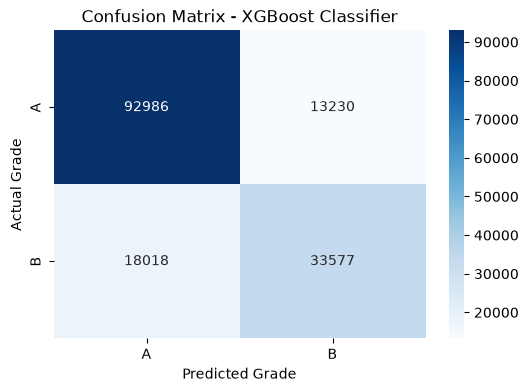

In [40]:
# Plot confusion matrix heatmap for XGBoost Classifier
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["A", "B"], yticklabels=["A", "B"])
plt.title("Confusion Matrix - XGBoost Classifier")
plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")
plt.show()

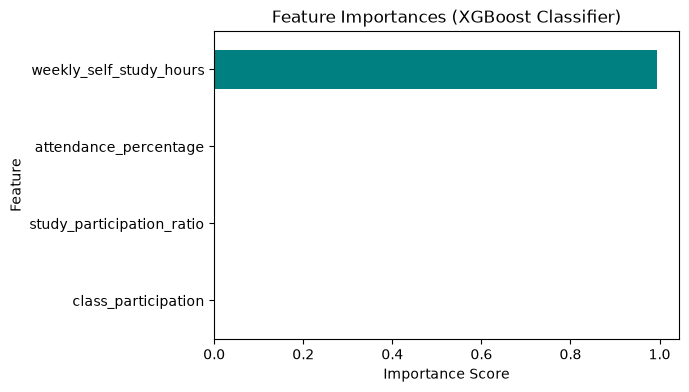

In [41]:
# Plot horizontal bar chart of feature importances from XGBoost Classifier
feature_importances = pd.Series(xgb_cls.feature_importances_, index=X.columns)
plt.figure(figsize=(6, 4))
feature_importances.sort_values().plot(kind="barh", color="teal")
plt.title("Feature Importances (XGBoost Classifier)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [42]:
# Create summary table comparing performance metrics across models
summary_df = pd.DataFrame({
    "Model": ["Decision Tree Classifier", "Random Forest Classifier", "XGBoost Classifier"],
    "Accuracy": [round(acc_dt, 4), round(acc_rf, 4), round(acc_xgb, 4)],
    "Precision": [round(prec_dt, 4), round(prec_rf, 4), round(prec_xgb, 4)],
    "Recall": [round(rec_dt, 4), round(rec_rf, 4), round(rec_xgb, 4)],
    "F1 Score": [round(f1_dt, 4), round(f1_rf, 4), round(f1_xgb, 4)]
})
summary_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree Classifier,0.8021,0.7219,0.6418,0.6795
1,Random Forest Classifier,0.8016,0.7094,0.6662,0.6871
2,XGBoost Classifier,0.8020,0.7173,0.6508,0.6824


In [51]:
x=[[13.4,79.6,8.1,100.0]]
a=scaler.transform(x)
res = xgb_cls.predict(a)

c:\Users\sumitme752\Desktop\mlops\class_1\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [50]:
a

array([[-0.60913152, -0.52755551,  1.07959781, -0.02801882]])

In [55]:
res

array([1])

In [56]:
x=res.tolist()

In [57]:
x[0]

1

In [ ]:
data ingestion
data preprocessing
feature Engineering
model building
model evaluation

In [59]:
import pickle
# Load the model from disk
with open('../models/xgboost.pkl', 'rb') as file:
    model = pickle.load(file)

In [61]:
x=[[13.4,79.6,8.1,100.0]]
a=scaler.transform(x)
res = (model.predict(a)).tolist()

c:\Users\sumitme752\Desktop\mlops\class_1\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [63]:
res[0]

1